Machine Learning
Goal: Use machine learning to classify right and left hand motor imagery from EEG. I will evaluate the performance across all 9 participants in the dataset.

In [60]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mne.decoding import CSP

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [61]:
def load_subject(subject_number):

    file_path = f"../data/BCICIV_2a_gdf/A{subject_number:02d}T.gdf"

    raw = mne.io.read_raw_gdf(
        file_path,
        preload=True,
        verbose=False
    )

    return raw

In [62]:
def prepare_subject(subject_number):

    raw = load_subject(subject_number)

    events, event_id = mne.events_from_annotations(
        raw,
        event_id="auto",
        verbose=False
    )

    left_hand_code = event_id["769"]
    right_hand_code = event_id["770"]

    motor_events = {
        "left_hand": left_hand_code,
        "right_hand": right_hand_code
    }

    epochs = mne.Epochs(
        raw,
        events,
        event_id=motor_events,
        tmin=-0.5,
        tmax=4.0,
        baseline=(-0.5, 0),
        preload=True,
        verbose=False
    )

    eog_channels = [
        "EOG-left",
        "EOG-central",
        "EOG-right"
    ]

    for channel in eog_channels:
        if channel in epochs.ch_names:
            epochs.drop_channels(channel)

    epochs.filter(l_freq=8, h_freq=30, verbose=False)
    epochs.crop(tmin=0.5, tmax=3.5)

    X = epochs.get_data()
    y = epochs.events[:, 2]

    return X, y

In [63]:
# Using a 5-fold stratified cross-validation to evaluate each subject acrossmultiple train/test splits
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [64]:
# CSP + LDA
lda_results = []

for subject in range(1, 10):

    print("Processing subject", subject)

    X, y = prepare_subject(subject)

    model = Pipeline([
        (
            "CSP",
            CSP(
                n_components=6,
                log=True
            )
        ),
        (
            "LDA",
            LinearDiscriminantAnalysis()
        )
    ])

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    mean_accuracy = scores.mean()
    standard_deviation = scores.std()

    lda_results.append({
        "Subject": f"A{subject:02d}",
        "Mean Accuracy": mean_accuracy,
        "Std": standard_deviation
    })

    print(
        "Mean Accuracy:",
        round(mean_accuracy * 100, 2),
        "%"
    )

lda_df = pd.DataFrame(lda_results)

lda_df

Processing subject 1


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Computing rank from data with rank=None
    Using tolerance 3.1e-05 (2.2e-16 eps * 22 dim * 6.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.1e-05 (2.2e-16 eps * 22 dim * 6.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.1e-05 (2.2e-16 eps * 22 dim * 6.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMP

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Computing rank from data with rank=None
    Using tolerance 3.6e-05 (2.2e-16 eps * 22 dim * 7.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.6e-05 (2.2e-16 eps * 22 dim * 7.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.6e-05 (2.2e-16 eps * 22 dim * 7.4e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMP

...

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Computing rank from data with rank=None
    Using tolerance 5.6e-05 (2.2e-16 eps * 22 dim * 1.1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.5e-05 (2.2e-16 eps * 22 dim * 1.1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.6e-05 (2.2e-16 eps * 22 dim * 1.1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMP

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Computing rank from data with rank=None
    Using tolerance 5.2e-05 (2.2e-16 eps * 22 dim * 1.1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.1e-05 (2.2e-16 eps * 22 dim * 1.1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.1e-05 (2.2e-16 eps * 22 dim * 1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIR

,Subject,Mean Accuracy,Std
0,A01,0.853941,0.041123
1,A02,0.590640,0.064725
2,A03,0.979310,0.027586
3,A04,0.715764,0.094930
4,A05,0.610837,0.029392
5,A06,0.597291,0.109969
6,A07,0.763793,0.034310
7,A08,0.986207,0.016893
8,A09,0.805911,0.045640


Average accuracy across subjects: 76.71 %
Standard deviation across subjects: 15.38 %


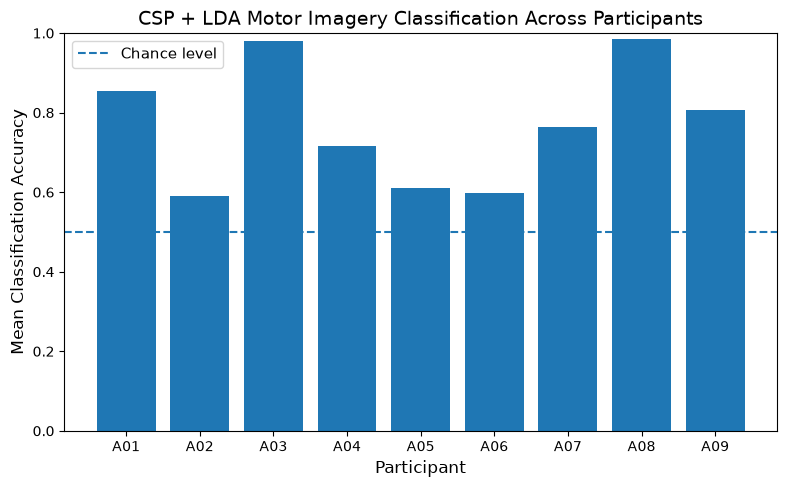

In [77]:
overall_mean = lda_df["Mean Accuracy"].mean()

overall_std = lda_df["Mean Accuracy"].std()

print(
    "Average accuracy across subjects:",
    round(overall_mean * 100, 2),
    "%"
)

print(
    "Standard deviation across subjects:",
    round(overall_std * 100, 2),
    "%"
)

plt.figure()

plt.bar(
    lda_df["Subject"],
    lda_df["Mean Accuracy"]
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Chance level"
)

plt.xlabel("Participant")
plt.ylabel("Mean Classification Accuracy")

plt.title(
    "CSP + LDA Motor Imagery Classification Across Participants"
)

plt.ylim(0, 1)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/subject_classification_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Classification performance varies substantially between the participants. This suggests that motor imagery signals are not equally as easy to decode for every participant.

Classifier Comparison

I will keep CSP as the fised feature extraction method and compare the following classifiers:
- Linear Discriminant Analysis (LDA)
- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest

Keeping CSP fixed allows me to compare the classfiers evenly.

In [66]:
classifier_results = []
for subject in range(1, 10):

    print("Processing subject", subject)

    X, y = prepare_subject(subject)

    lda_model = Pipeline([
        (
            "CSP",
            CSP(
                n_components=6,
                log=True
            )
        ),
        (
            "LDA",
            LinearDiscriminantAnalysis()
        )
    ])
    lda_scores = cross_val_score(
        lda_model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )
    lda_mean = lda_scores.mean()
    lda_std = lda_scores.std()
    classifier_results.append({
            "Subject": f"A{subject:02d}",
            "Classifier": "LDA",
            "Mean Accuracy": lda_mean,
            "Standard Deviation": lda_std,
        })

    logistic_model = Pipeline([
        (
            "CSP",
            CSP(
                n_components=6,
                log=True
            )
        ),
        (
            "Logistic Regression",
            LogisticRegression(
                max_iter=1000
            )
        )
    ])
    logistic_scores = cross_val_score(
        logistic_model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    logistic_mean = logistic_scores.mean()
    logistic_std = logistic_scores.std()
    classifier_results.append({
        "Subject": f"A{subject:02d}",
        "Classifier": "Logistic Regression",
        "Mean Accuracy": logistic_mean,
        "Standard Deviation": logistic_std
 })


    svm_model = Pipeline([
        (
            "CSP",
            CSP(
                n_components=6,
                log=True
            )
        ),
        (
            "SVM",
            SVC()
        )
    ])

    svm_scores = cross_val_score(
        svm_model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    svm_mean = svm_scores.mean()
    svm_std = svm_scores.std()
    classifier_results.append({
        "Subject": f"A{subject:02d}",
        "Classifier": "SVM",
        "Mean Accuracy": svm_mean,
        "Standard Deviation": svm_std
    })

    rf_model = Pipeline([
        (
            "CSP",
            CSP(
                n_components=6,
                log=True
            )
        ),
        (
            "Random Forest",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ])
    rf_scores = cross_val_score(
        rf_model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )
    rf_mean = rf_scores.mean()
    rf_std = rf_scores.std()
    classifier_results.append({
        "Subject": f"A{subject:02d}",
        "Classifier": "Random Forest",
        "Mean Accuracy": rf_mean,
        "Standard Deviation": rf_std
    })

print("LDA:", round(lda_mean * 100, 2), "%")
print("Logistic Regression:", round(logistic_mean * 100, 2), "%")
print("SVM:", round(svm_mean * 100, 2), "%")
print("Random Forest:", round(rf_mean * 100, 2), "%")

Processing subject 1


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Computing rank from data with rank=None
    Using tolerance 3.1e-05 (2.2e-16 eps * 22 dim * 6.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.1e-05 (2.2e-16 eps * 22 dim * 6.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.1e-05 (2.2e-16 eps * 22 dim * 6.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMP

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Computing rank from data with rank=None
    Using tolerance 3.6e-05 (2.2e-16 eps * 22 dim * 7.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.6e-05 (2.2e-16 eps * 22 dim * 7.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.6e-05 (2.2e-16 eps * 22 dim * 7.4e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMP

...

Computing rank from data with rank=None
    Using tolerance 2.8e-05 (2.2e-16 eps * 22 dim * 5.8e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.8e-05 (2.2e-16 eps * 22 dim * 5.7e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.7e-05 (2.2e-16 eps * 22 dim * 5.6e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMP

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Computing rank from data with rank=None
    Using tolerance 5.6e-05 (2.2e-16 eps * 22 dim * 1.1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.5e-05 (2.2e-16 eps * 22 dim * 1.1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.6e-05 (2.2e-16 eps * 22 dim * 1.1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMP

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Computing rank from data with rank=None
    Using tolerance 5.2e-05 (2.2e-16 eps * 22 dim * 1.1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.1e-05 (2.2e-16 eps * 22 dim * 1.1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.1e-05 (2.2e-16 eps * 22 dim * 1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIR

In [67]:
classifier_df = pd.DataFrame(classifier_results)

classifier_df

classifier_means = (
    classifier_df
    .groupby("Classifier")["Mean Accuracy"]
    .mean()
)
for classifier, accuracy in classifier_means.items():
    print(classifier, ":", round(accuracy * 100, 2), "%")


LDA : 76.71 %
Logistic Regression : 77.01 %
Random Forest : 75.86 %
SVM : 76.55 %


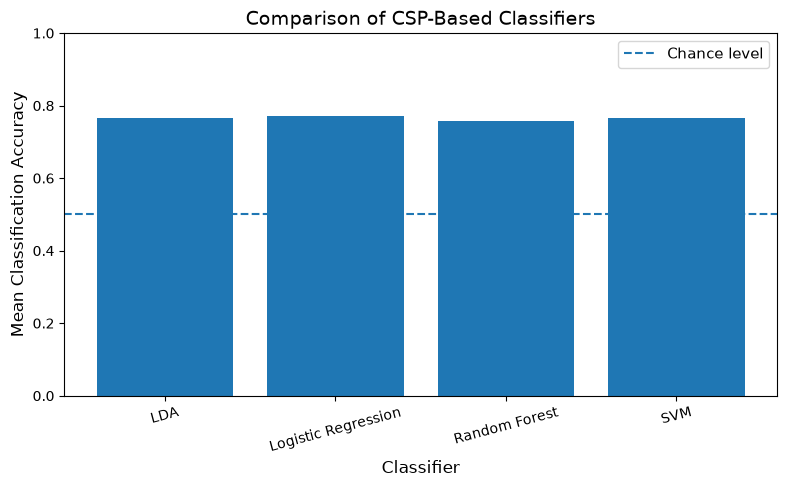

In [78]:
plt.figure()

plt.bar(
    classifier_means.index,
    classifier_means.values
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Chance level"
)

plt.xlabel("Classifier")
plt.ylabel("Mean Classification Accuracy")

plt.title(
    "Comparison of CSP-Based Classifiers"
)

plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/classifier_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Classifier Comparison Results

I compared four classifiers while keeping CSP fixed as the feature extraction method. The classifiers achieved relatively similar average accuracies across participants This suggests that classifier choice had a smaller effect on performance than differences between participants or the type of EEG features used.

Feature Representation
While keeping the classifer fixed as LDA, I will compare the following feature representaions:
- CSP
- Band Power
- Hjorth Parameters

Goal: How does the representation of the EEg signal affect classification performance?

In [69]:
from sklearn.preprocessing import StandardScaler


feature_results = []
for subject in range(1, 10):

    print("Processing subject", subject)

    X, y = prepare_subject(subject)
    csp_model = Pipeline([
        (
            "CSP",
            CSP(
                n_components=6,
                log=True
            )
        ),
        (
            "LDA",
            LinearDiscriminantAnalysis()
        )
    ])
    csp_scores = cross_val_score(
        csp_model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    csp_mean = csp_scores.mean()
    feature_results.append({
        "Subject": f"A{subject:02d}",
        "Feature Set": "CSP",
        "Mean Accuracy": csp_mean
    })
    sfreq = 250
    bandpower_features = []

    for trial in X:

        trial_features = []

        for channel in trial:

            psd, freqs = mne.time_frequency.psd_array_welch(
                channel,
                sfreq=sfreq,
                fmin=8,
                fmax=30,
                verbose=False
            )

            mu_mask = (freqs >= 8) & (freqs < 13)
            beta_mask = (freqs >= 13) & (freqs <= 30)

            mu_power = psd[mu_mask].mean()
            beta_power = psd[beta_mask].mean()

            trial_features.append(mu_power)
            trial_features.append(beta_power)

    bandpower_features.append(trial_features)

    x_bandpower = np.array(bandpower_features)

    bandpower_model = Pipeline([
        (
            "Scaler",
            StandardScaler()
        ),
        (
            "LDA",
            LinearDiscriminantAnalysis()
        )
        ])
    bandpower_features = []

    for trial in X:
        trial_features = []

        for channel in trial:
            psd, freqs = mne.time_frequency.psd_array_welch(
                channel,
                sfreq=250,
                fmin=8,
                fmax=30,
                verbose=False
            )

            mu_mask = (freqs >= 8) & (freqs < 13)
            beta_mask = (freqs >= 13) & (freqs <= 30)

            mu_power = psd[mu_mask].mean()
            beta_power = psd[beta_mask].mean()

            trial_features.extend([mu_power, beta_power])

        bandpower_features.append(trial_features)

    x_bandpower = np.asarray(bandpower_features, dtype=float)

    bandpower_scores = cross_val_score(
        bandpower_model,
        x_bandpower,
        y,
        cv=cv,
        scoring="accuracy"
    )

    bandpower_mean = bandpower_scores.mean()
    feature_results.append({
        "Subject": f"A{subject:02d}",
        "Feature Set": "Band Power",
        "Mean Accuracy": bandpower_mean
    })

    hjorth_features = []

    for trial in X:

        trial_features = []

        for channel in trial:

            # compute Hjorth parameters inline (avoids undefined calculate_hjorth)
            dc = np.diff(channel)
            ddc = np.diff(channel, n=2) if channel.size > 2 else np.array([])
            activity = np.var(channel)
            var_dc = np.var(dc) if dc.size > 0 else 0.0
            var_ddc = np.var(ddc) if ddc.size > 0 else 0.0

            if activity <= 0 or var_dc <= 0:
                mobility = 0.0
                complexity = 0.0
            else:
                mobility = np.sqrt(var_dc / activity)
                mobility_dc = np.sqrt(var_ddc / var_dc) if var_ddc > 0 else 0.0
                complexity = mobility_dc / mobility if mobility > 0 else 0.0

            trial_features.append(activity)
            trial_features.append(mobility)
            trial_features.append(complexity)

        hjorth_features.append(trial_features)

    x_hjorth = np.array(hjorth_features)
    hjorth_model = Pipeline([
        (
            "Scaler",
            StandardScaler()
        ),
        (
            "LDA",
            LinearDiscriminantAnalysis()
        )
    ])

    hjorth_scores = cross_val_score(
        hjorth_model,
        x_hjorth,
        y,
        cv=cv,
        scoring="accuracy"
    )

    hjorth_mean = hjorth_scores.mean()

    feature_results.append({
        "Subject": f"A{subject:02d}",
        "Feature Set": "Hjorth",
        "Mean Accuracy": hjorth_mean
    })

print("CSP:", round(csp_mean * 100, 2), "%")
print("Band Power:", round(bandpower_mean * 100, 2), "%")
print("Hjorth:", round(hjorth_mean * 100, 2), "%")


Processing subject 1


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Computing rank from data with rank=None
    Using tolerance 3.1e-05 (2.2e-16 eps * 22 dim * 6.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.1e-05 (2.2e-16 eps * 22 dim * 6.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.1e-05 (2.2e-16 eps * 22 dim * 6.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMP

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Computing rank from data with rank=None
    Using tolerance 3.6e-05 (2.2e-16 eps * 22 dim * 7.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.6e-05 (2.2e-16 eps * 22 dim * 7.3e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.6e-05 (2.2e-16 eps * 22 dim * 7.4e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMP

...

Computing rank from data with rank=None
    Using tolerance 2.8e-05 (2.2e-16 eps * 22 dim * 5.8e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.8e-05 (2.2e-16 eps * 22 dim * 5.7e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.7e-05 (2.2e-16 eps * 22 dim * 5.6e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMP

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Computing rank from data with rank=None
    Using tolerance 5.6e-05 (2.2e-16 eps * 22 dim * 1.1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.5e-05 (2.2e-16 eps * 22 dim * 1.1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.6e-05 (2.2e-16 eps * 22 dim * 1.1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMP

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Computing rank from data with rank=None
    Using tolerance 5.2e-05 (2.2e-16 eps * 22 dim * 1.1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.1e-05 (2.2e-16 eps * 22 dim * 1.1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.1e-05 (2.2e-16 eps * 22 dim * 1e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIR

In [70]:
feature_df = pd.DataFrame(feature_results)

feature_df

feature_means = (
    feature_df
    .groupby("Feature Set")["Mean Accuracy"]
    .mean()
)

for feature, accuracy in feature_means.items():
    print(feature, ":", round(accuracy * 100, 2), "%")

Band Power : 62.66 %
CSP : 76.71 %
Hjorth : 70.07 %


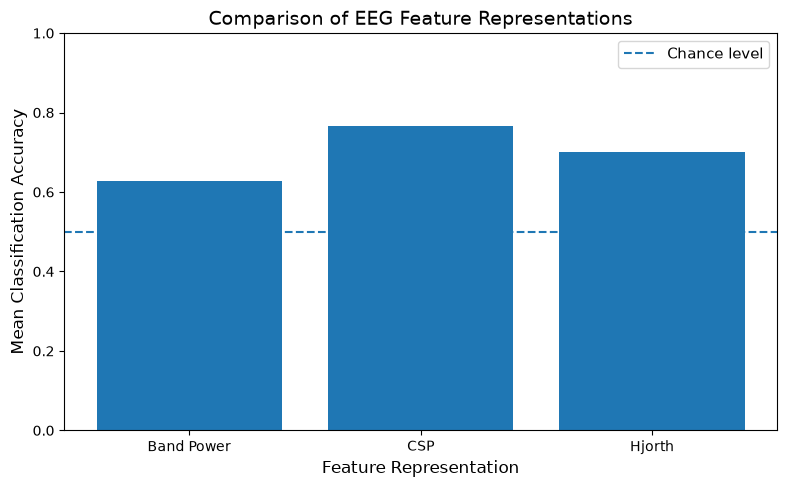

In [79]:
plt.figure()

plt.bar(
    feature_means.index,
    feature_means.values
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Chance level"
)

plt.xlabel("Feature Representation")
plt.ylabel("Mean Classification Accuracy")

plt.title(
    "Comparison of EEG Feature Representations"
)

plt.ylim(0, 1)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/feature_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [72]:
feature_pivot = feature_df.pivot(
    index="Subject",
    columns="Feature Set",
    values="Mean Accuracy"
)

feature_pivot

Feature Set,Band Power,CSP,Hjorth
Subject,,,
A01,0.598276,0.853941,0.659852
A02,0.583744,0.590640,0.576355
A03,0.701232,0.979310,0.764286
A04,0.540640,0.715764,0.680788
A05,0.520197,0.610837,0.687931
A06,0.541626,0.597291,0.589901
A07,0.603941,0.763793,0.701232
A08,0.771675,0.986207,0.861084
A09,0.778325,0.805911,0.785222


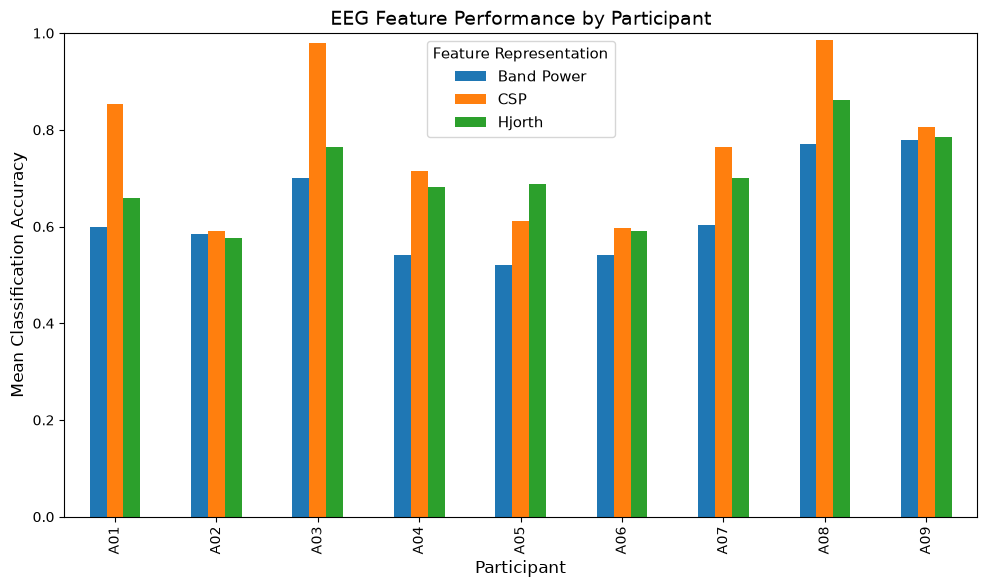

In [80]:
feature_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Participant")
plt.ylabel("Mean Classification Accuracy")

plt.title(
    "EEG Feature Performance by Participant"
)

plt.ylim(0, 1)

plt.legend(
    title="Feature Representation"
)

plt.tight_layout()

plt.savefig(
    "../figures/feature_by_subject.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

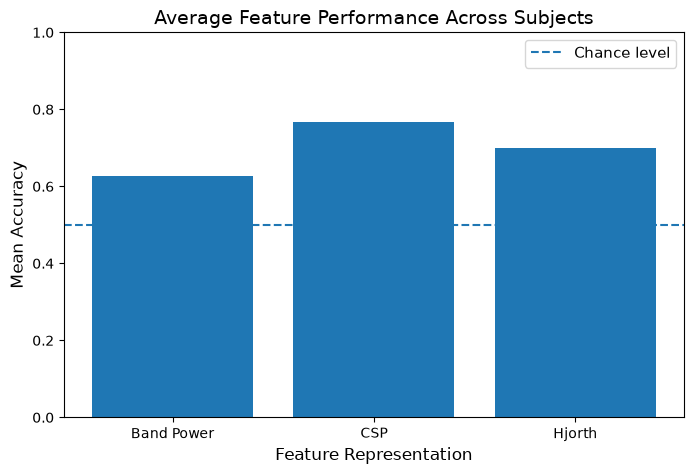

In [74]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_means.index,
    feature_means.values
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Chance level"
)

plt.ylim(0, 1)

plt.xlabel("Feature Representation")
plt.ylabel("Mean Accuracy")

plt.title(
    "Average Feature Performance Across Subjects"
)

plt.legend()

plt.show()

In [75]:
classifier_pivot = classifier_df.pivot(
    index="Subject",
    columns="Classifier",
    values="Mean Accuracy"
)

classifier_pivot

Classifier,LDA,Logistic Regression,Random Forest,SVM
Subject,,,,
A01,0.853941,0.819212,0.812069,0.846798
A02,0.590640,0.632266,0.605172,0.598030
A03,0.979310,0.979310,0.958374,0.965271
A04,0.715764,0.687685,0.687931,0.736700
A05,0.610837,0.624877,0.568719,0.597044
A06,0.597291,0.631527,0.688177,0.617734
A07,0.763793,0.757143,0.743103,0.750000
A08,0.986207,0.972414,0.958374,0.979310
A09,0.805911,0.826355,0.805419,0.798768


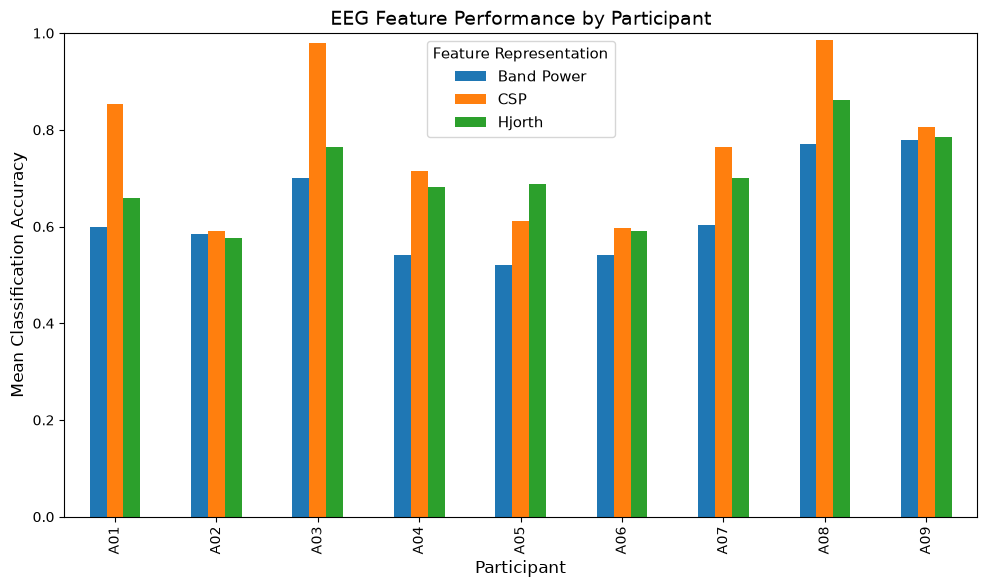

In [81]:
feature_pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Participant")
plt.ylabel("Mean Classification Accuracy")

plt.title(
    "EEG Feature Performance by Participant"
)

plt.ylim(0, 1)

plt.legend(
    title="Feature Representation"
)

plt.tight_layout()

plt.savefig(
    "../figures/feature_by_subject.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

I evaluated left- versus right-hand motor imagery classification across all 9 participants. Keeping CSP fixed as the feature extraction method, I compared four classifiers and they all performed relatively similarly. This suggests that classifer choice had a smaller effect on performance. I then compared CSP, Band Power, and Hjorth Parameter representations while keeping LDA fixed as the classifer. CSP generally produced the strongest classification performance. The results also varried a lot between participants, highlighting the subject-dependent nature of EEG-based motor imagery classification.